## AI4Climate ML tutorial - Inference and Visualisation
* Author: Stephen Haddad
* Affiliation: UK Met Office
* History: 1.0
* Last update: 2026-03-16
* © British Crown Copyright 2017-2026, Met Office. Please see LICENSE.md for license details.

## Overview of the broad topic covered
In the previous notebooks we have explored and prepared a dataset for training a machine learning model, then we have trained a few different algorithms using this data. The next step is to use the trained model,  both to evaluate and understand how well it has learned the relationship in the data we want it to learn, but also then aplying to the intended use of the data. For example if we have trained a global climate model, we want to use the trained model for experiments around climate change and climate variability, for example.  In this notebook we will look at running inference with the model and visualising the results.


### Prerequisites 
- Same as previous notebooks
- Have completed model training pipeline notebook


### Learning outcomes from completing the notebook
* Load a saved model
* Make predictions with the model
* Visualise the results

## Tutorial 
a balance of explanation and activity



In [1]:
import pathlib
import os
import datetime
import json

In [2]:
import pickle

In [3]:
import numpy

In [4]:
import pandas

In [5]:
import iris
import cartopy.crs

In [6]:
import matplotlib.pyplot

In [7]:
import sklearn
import sklearn.preprocessing
import sklearn.tree

In [8]:
import xarray

In [9]:
with open ('config.json','r') as tutorial_config:
    tutorial_config = json.load(tutorial_config)
tutorial_config

{'platform': 'jasmin',
 'default_dirs': {'mo_linux': '/data/users/dscop/ml_tutorial/',
  'jasmin': '/gws/ssde/j25b/ai4climate/data'},
 'random_seed': 12345,
 'climate_subgroups': {'non-land': 'None',
  'Af': 'Tropical, rainforest',
  'Am': 'Tropical, monsoon',
  'Aw': 'Tropical, savannah',
  'BWh': 'Arid, desert, hot',
  'BWk': 'Arid, desert, cold',
  'BSh': 'Arid, steppe, hot',
  'BSk': 'Arid, steppe, cold',
  'Csa': 'Temperate, dry summer, hot summer',
  'Csb': 'Temperate, dry summer, warm summer',
  'Csc': 'Temperate, dry summer, cold summer',
  'Cwa': 'Temperate, dry winter, hot summer',
  'Cwb': 'Temperate, dry winter, warm summer',
  'Cwc': 'Temperate, dry winter, cold summer',
  'Cfa': 'Temperate, no dry season, hot summer',
  'Cfb': 'Temperate, no dry season, warm summer',
  'Cfc': 'Temperate, no dry season, cold summer',
  'Dsa': 'Cold, dry summer, hot summer',
  'Dsb': 'Cold, dry summer, warm summer',
  'Dsc': 'Cold, dry summer, cold summer',
  'Dsd': 'Cold, dry summer, very 

In [10]:
def get_platform_dir(select_platform, config):
    try:
        root_path = pathlib.Path(config['default_dirs'][select_platform]) / 'climate_zones'
    except KeyError:
        root_path = pathlib.Path(os.environ['HOME']) / 'climate_zones'
    return root_path

In [11]:
current_platform = tutorial_config['platform']

In [12]:
root_data_dir = get_platform_dir(current_platform, tutorial_config)

print(root_data_dir.is_dir())
root_data_dir

True


PosixPath('/gws/ssde/j25b/ai4climate/data/climate_zones')

In [13]:
ml_ready_dir = root_data_dir / 'ml_ready'
print(ml_ready_dir.is_dir())
ml_ready_dir

True


PosixPath('/gws/ssde/j25b/ai4climate/data/climate_zones/ml_ready')

In [14]:
resolutions_dict = {float(k1): v1 for k1,v1 in tutorial_config['resolutions_names'].items()}

dataset_prefix_dict = tutorial_config['dataset_prefix']

format_str = 'nc'
historic_scenario_str = 'historic'

future_scenario_list = tutorial_config['future_scenarios']
historic_scenario_list = tutorial_config['historic_scenarios']

time_periods = { 
    (1901,1930): historic_scenario_list, 
    (1931,1960): historic_scenario_list,
    (1961,1990): historic_scenario_list,
    (1991,2020): historic_scenario_list,
    (2041,2070): future_scenario_list,
    (2071,2099): future_scenario_list,
}


In [15]:
fname_template = tutorial_config['fname_template']
time_dir_template = tutorial_config['time_dir_template']
ml_ready_fname_template = tutorial_config['csv_out_template']

### Load data for inference

In [16]:
current_res = 1.0

In [17]:
mlready_data_path = ml_ready_dir / ml_ready_fname_template.format(resolution=resolutions_dict[current_res])
print(mlready_data_path.is_file())
mlready_data_path

True


PosixPath('/gws/ssde/j25b/ai4climate/data/climate_zones/ml_ready/climate_zones_1p0.csv')

In [18]:
zones_df = pandas.read_csv(mlready_data_path)

In [19]:
# reducing the total data point to decrease memeory requirements
# zones_df = zones_df[(zones_df['period_start']==1991)&(zones_df['scenario']=='historic')]

In [20]:
zones_df

,lat,lon,precipitation_1.0_mean,precipitation_2.0_mean,precipitation_3.0_mean,precipitation_4.0_mean,precipitation_5.0_mean,precipitation_6.0_mean,precipitation_7.0_mean,precipitation_8.0_mean,...,air_temperature_10.0_std,air_temperature_11.0_std,air_temperature_12.0_std,kg_class,kg_confidence,period_start,period_end,scenario,climate_group,climate_subgroup
0,83.5,-38.5,12.1250,8.2500,8.9375,21.8750,15.5000,29.8750,35.8750,46.1250,...,2.5625,3.3125,3.6250,29.0,83.0,1901,1930,historic,E,E
1,83.5,-37.5,10.8750,8.1250,8.6250,19.6250,13.8125,26.8750,32.0625,42.0000,...,3.0000,3.8125,4.1250,30.0,86.0,1901,1930,historic,E,E
2,83.5,-36.5,9.9375,8.4375,8.8125,18.1250,12.3750,23.6875,28.5000,37.8125,...,2.5000,3.1875,3.4375,30.0,84.0,1901,1930,historic,E,E
3,83.5,-35.5,10.0000,8.8750,9.0625,17.6250,12.0000,22.4375,26.9375,35.9375,...,2.3750,3.1250,3.4375,30.0,86.0,1901,1930,historic,E,E
4,83.5,-34.5,10.1250,9.1875,9.4375,16.7500,11.3750,20.6250,24.9375,33.3750,...,1.9375,2.5000,2.8750,30.0,76.0,1901,1930,historic,E,E
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
406489,-89.5,175.5,4.0000,4.5625,6.6250,7.0000,7.1875,5.7500,5.6250,8.3125,...,1.1250,1.1250,1.4375,30.0,100.0,2071,2099,ssp585,E,E
406490,-89.5,176.5,4.0000,4.5625,6.6875,7.0625,7.2500,5.8125,5.6250,8.4375,...,1.1250,1.1250,1.4375,30.0,100.0,2071,2099,ssp585,E,E
406491,-89.5,177.5,4.0625,4.6250,6.6875,7.1250,7.3125,5.8125,5.6875,8.7500,...,1.1250,1.1250,1.4375,30.0,100.0,2071,2099,ssp585,E,E
406492,-89.5,178.5,4.0625,4.6250,6.6875,7.1250,7.3125,5.8125,5.6875,9.0000,...,1.1250,1.1875,1.4375,30.0,100.0,2071,2099,ssp585,E,E


In [21]:
predictors_dict = {
    'precip_mean': [c1 for c1 in zones_df.columns if 'precipitation' in c1 and 'mean' in c1],
    'precip_std': [c1 for c1 in zones_df.columns if 'precipitation' in c1 and 'std' in c1],
    'temp_mean': [c1 for c1 in zones_df.columns if 'air_temperature' in c1 and 'mean' in c1],
    'temp_std': [c1 for c1 in zones_df.columns if 'air_temperature' in c1 and 'std' in c1],
}


In [22]:
predictors = predictors_dict['precip_mean'] + predictors_dict['temp_mean']
predictors

['precipitation_1.0_mean',
 'precipitation_2.0_mean',
 'precipitation_3.0_mean',
 'precipitation_4.0_mean',
 'precipitation_5.0_mean',
 'precipitation_6.0_mean',
 'precipitation_7.0_mean',
 'precipitation_8.0_mean',
 'precipitation_9.0_mean',
 'precipitation_10.0_mean',
 'precipitation_11.0_mean',
 'precipitation_12.0_mean',
 'air_temperature_1.0_mean',
 'air_temperature_2.0_mean',
 'air_temperature_3.0_mean',
 'air_temperature_4.0_mean',
 'air_temperature_5.0_mean',
 'air_temperature_6.0_mean',
 'air_temperature_7.0_mean',
 'air_temperature_8.0_mean',
 'air_temperature_9.0_mean',
 'air_temperature_10.0_mean',
 'air_temperature_11.0_mean',
 'air_temperature_12.0_mean']

We have two options for the target. We have the full 30 class climate subgroups of the Koppen-Geiger classification data from the original dataset. We also have the processed five class climate group target, which presents an easier target for our classification algorithm to predict.

In [23]:
target_var = 'climate_group' # 5 classes
# target_var = 'climate_subgroup # 30 classes


In [24]:
random_seed = tutorial_config['random_seed']

In [25]:
test_frac = 0.1
val_frac = 0.1
val_frac_sub = (val_frac / (1.0-test_frac) )

In [26]:
test_df = zones_df.groupby(['period_start','scenario']).sample(frac=test_frac, random_state=random_seed)
remain_df = zones_df.drop(test_df.index)

In [27]:
val_df = remain_df.groupby(['period_start','scenario']).sample(frac=val_frac_sub, random_state=random_seed)
train_df = remain_df.drop(val_df.index)


In [28]:
with open('stats.json','r') as stats_file:
    stats_dict = json.load(stats_file)


In [29]:
input_scaler = sklearn.preprocessing.StandardScaler()
input_scaler.mean_ = numpy.array(stats_dict['input_mean'])
input_scaler.scale_ = numpy.array(stats_dict['input_scale'])


In [30]:
X_train = input_scaler.transform(train_df[predictors])
X_val = input_scaler.transform(val_df[predictors])
X_test = input_scaler.transform(test_df[predictors])

/gws/ssde/j25b/ai4climate/user/shaddad/venv/ai4c_nb_cpu/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/gws/ssde/j25b/ai4climate/user/shaddad/venv/ai4c_nb_cpu/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/gws/ssde/j25b/ai4climate/user/shaddad/venv/ai4c_nb_cpu/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [31]:
train_df[[target_var]].value_counts()

climate_group
E                116146
D                 80766
B                 60790
A                 40252
C                 27252
Name: count, dtype: int64

In [32]:
numpy.array(stats_dict['target_classes']).shape

(5,)

In [33]:
target_encoder = sklearn.preprocessing.LabelEncoder()
target_encoder.classes_ = numpy.array(stats_dict['target_classes'],dtype='object')

In [34]:
y_train = target_encoder.transform(train_df[target_var])
y_val = target_encoder.transform(val_df[target_var])
y_test = target_encoder.transform(test_df[target_var])


In [35]:
algorithm_name = 'decision_tree'

In [36]:
%%time
load_pretrain=True
if load_pretrain:
    with open(f'{algorithm_name}.pkl', 'rb') as f:
        dt_clf = pickle.load(f)
else:
    dt_opts = {'max_depth':10, 'min_samples_leaf': 2, 'min_samples_split': 5}
    dt_clf = sklearn.tree.DecisionTreeClassifier(**dt_opts)
    dt_clf.fit(X_train, y_train) 

CPU times: user 0 ns, sys: 588 μs, total: 588 μs
Wall time: 2.46 ms


In [37]:
dt_clf

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [38]:
y_pred_train = dt_clf.predict(X_train)
y_pred_val = dt_clf.predict(X_val)

In [39]:
train_df['climate_group_prediction_dt'] = target_encoder.inverse_transform(y_pred_train)
train_df

,lat,lon,precipitation_1.0_mean,precipitation_2.0_mean,precipitation_3.0_mean,precipitation_4.0_mean,precipitation_5.0_mean,precipitation_6.0_mean,precipitation_7.0_mean,precipitation_8.0_mean,...,air_temperature_11.0_std,air_temperature_12.0_std,kg_class,kg_confidence,period_start,period_end,scenario,climate_group,climate_subgroup,climate_group_prediction_dt
0,83.5,-38.5,12.1250,8.2500,8.9375,21.8750,15.5000,29.8750,35.8750,46.1250,...,3.3125,3.6250,29.0,83.0,1901,1930,historic,E,E,E
1,83.5,-37.5,10.8750,8.1250,8.6250,19.6250,13.8125,26.8750,32.0625,42.0000,...,3.8125,4.1250,30.0,86.0,1901,1930,historic,E,E,E
2,83.5,-36.5,9.9375,8.4375,8.8125,18.1250,12.3750,23.6875,28.5000,37.8125,...,3.1875,3.4375,30.0,84.0,1901,1930,historic,E,E,E
3,83.5,-35.5,10.0000,8.8750,9.0625,17.6250,12.0000,22.4375,26.9375,35.9375,...,3.1250,3.4375,30.0,86.0,1901,1930,historic,E,E,E
4,83.5,-34.5,10.1250,9.1875,9.4375,16.7500,11.3750,20.6250,24.9375,33.3750,...,2.5000,2.8750,30.0,76.0,1901,1930,historic,E,E,E
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
406488,-89.5,174.5,3.9375,4.5625,6.5625,6.9375,7.1250,5.6875,5.5625,8.2500,...,1.1250,1.3750,30.0,100.0,2071,2099,ssp585,E,E,E
406489,-89.5,175.5,4.0000,4.5625,6.6250,7.0000,7.1875,5.7500,5.6250,8.3125,...,1.1250,1.4375,30.0,100.0,2071,2099,ssp585,E,E,E
406490,-89.5,176.5,4.0000,4.5625,6.6875,7.0625,7.2500,5.8125,5.6250,8.4375,...,1.1250,1.4375,30.0,100.0,2071,2099,ssp585,E,E,E
406492,-89.5,178.5,4.0625,4.6250,6.6875,7.1250,7.3125,5.8125,5.6875,9.0000,...,1.1875,1.4375,30.0,100.0,2071,2099,ssp585,E,E,E


In [40]:
val_df['climate_group_prediction_dt'] = target_encoder.inverse_transform(y_pred_val)

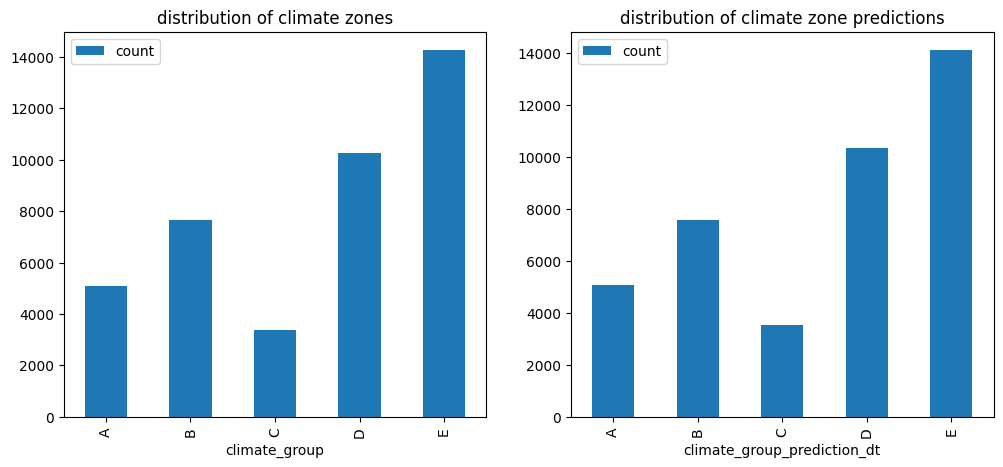

In [41]:
fig1 = matplotlib.pyplot.figure(figsize=(12,5))

ax1 = fig1.add_subplot(1,2,1,title='distribution of climate zones')
_ = pandas.DataFrame(val_df['climate_group'].value_counts(sort=False)).sort_values(axis=0,by='climate_group').plot.bar(ax=ax1)

ax1 = fig1.add_subplot(1,2,2,title='distribution of climate zone predictions')
_ = pandas.DataFrame(val_df['climate_group_prediction_dt'].value_counts(sort=False)).sort_values(axis=0,by='climate_group_prediction_dt').plot.bar(ax=ax1)


### Visualise on a map

In [42]:
climate_group_ds = xarray.open_dataset(root_data_dir / '2071_2099' / 'ssp434' /'koppen_geiger_1p0.nc')['kg_class']
climate_group_ds_pred = xarray.open_dataset(root_data_dir / '2071_2099' / 'ssp434' /'koppen_geiger_1p0.nc')['kg_class']

climate_group_ds

<xarray.DataArray 'kg_class' (lat: 180, lon: 360)> Size: 259kB
[64800 values with dtype=float32]
Coordinates:
  * lat      (lat) float64 1kB 89.5 88.5 87.5 86.5 ... -86.5 -87.5 -88.5 -89.5
  * lon      (lon) float64 3kB -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
Attributes:
    units:

In [43]:
scenario_df = zones_df[(zones_df['scenario'] == 'ssp434') & (zones_df['period_start'] == 2071)]

In [44]:
scenario_df['climate_group_pred_dt'] = target_encoder.inverse_transform(dt_clf.predict(input_scaler.transform(scenario_df[predictors])))
scenario_df['climate_group_pred_dt_raw'] = dt_clf.predict(input_scaler.transform(scenario_df[predictors]))

/gws/ssde/j25b/ai4climate/user/shaddad/venv/ai4c_nb_cpu/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/tmp/ipykernel_3804/3040866891.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scenario_df['climate_group_pred_dt'] = target_encoder.inverse_transform(dt_clf.predict(input_scaler.transform(scenario_df[predictors])))
/gws/ssde/j25b/ai4climate/user/shaddad/venv/ai4c_nb_cpu/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/tmp/ipykernel_3804/3040866891.py:2: SettingWithCopyWarning: 
A value is trying to be set on

In [45]:
climate_group_ds_pred.data =numpy.zeros(climate_group_ds.data.shape)

In [46]:
for row1 in scenario_df.iterrows():
    # print(row1[1]['climate_group_pred_dt'])
    climate_group_ds_pred.loc[{'lat':float(row1[1]['lat']), 'lon':float(row1[1]['lon'])} ] = int(row1[1]['climate_group_pred_dt_raw'])
    

Text(0.5, 1.0, 'KG CLimate Zones predicted')

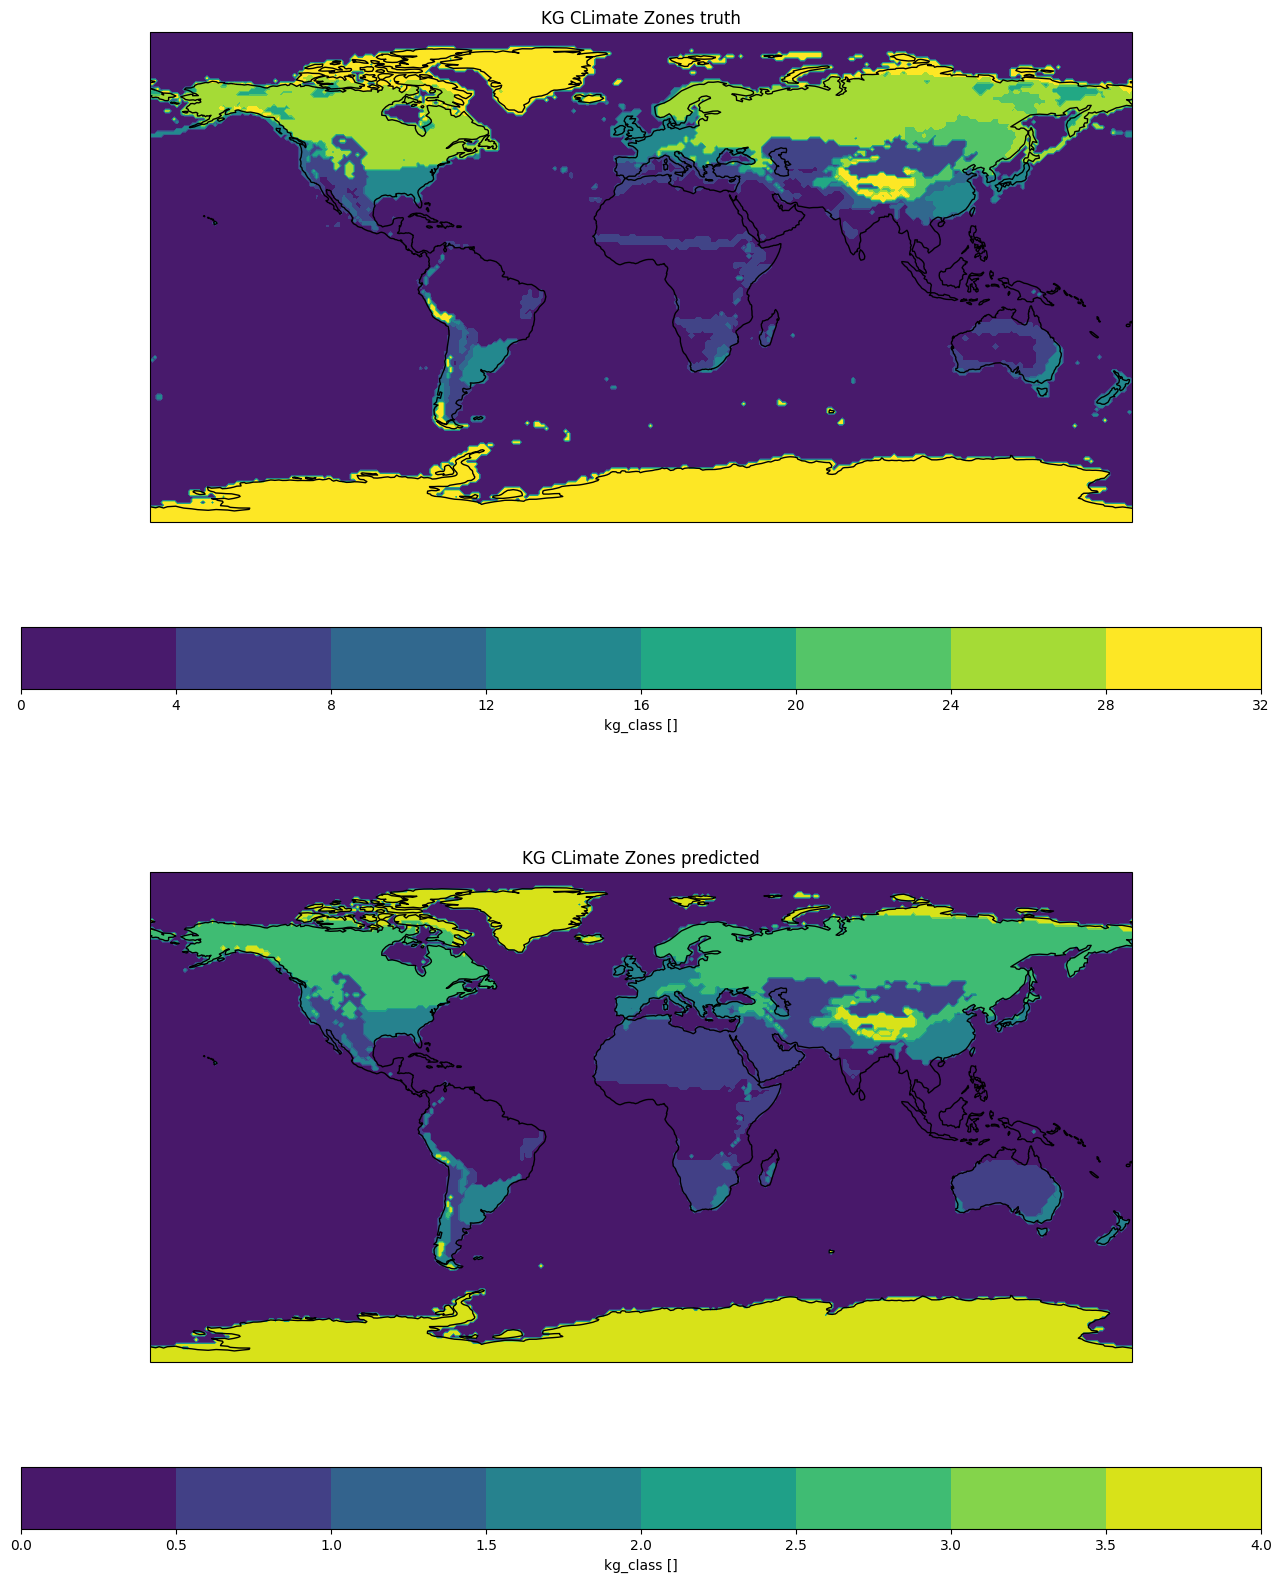

In [47]:
fig1 = matplotlib.pyplot.figure(figsize=(16,20))
ax1 = fig1.add_subplot(2,1,1 ,projection=cartopy.crs.PlateCarree(),)
climate_group_ds.plot.contourf(ax=ax1, 
                               transform=cartopy.crs.PlateCarree(),
                               cbar_kwargs={"location": "bottom"},
                              )
ax1.coastlines()
ax1.set_title(f'KG CLimate Zones truth')

ax1 = fig1.add_subplot(2,1,2 ,projection=cartopy.crs.PlateCarree(),)
climate_group_ds_pred.plot.contourf(ax=ax1, 
                                    transform=cartopy.crs.PlateCarree(),
                                    cbar_kwargs={"location": "bottom"},
                                   )
ax1.coastlines()
ax1.set_title(f'KG CLimate Zones predicted')

### Data statement
This data used in this notebook is derived from the Koppen-Geiger Climate Cliassfication dataset created by GloH2O.

###     References
- [Climate Zones Dataset](https://www.gloh2o.org/koppen/#:~:text=The%20K%C3%B6ppen%2DGeiger%20climate%20classification%20maps%20are%20high%2Dresolution,Climate%20Sensitivity%20(ECS)%2C%20and%20historical%20warming%20trend)